# Úkol 4 – MLP síť a jednoduchá ablační studie

V tomto notebooku navazuji na předchozí porovnání klasických modelů. V Úkolu 3 jsem neuronové sítě nepoužíval, protože tam byly ze zadání vynechané. Tady už je zkouším jako jednu z technik z workshopu.

Cílem není tvrdit, že neuronová síť je automaticky nejlepší model pro tabulková data. Chci hlavně ověřit, jestli jednoduché MLP v PyTorchi dokáže na stejných datech rozumně predikovat výnos plodin a jak se výsledek změní při jiné velikosti sítě nebo jiné aktivační funkci.


## Data a kontrola úniku informací

Používám stejné zpracované datasety jako v předchozích částech projektu:

- train: 1997–2010,
- validation: 2011–2012,
- test: 2013–2014.

Cílová proměnná je výnos plodiny (`target_yield`). Do vstupních proměnných nedávám produkci ani samotný výnos, aby model neměl k dispozici informaci přímo odvozenou z targetu.

Číselné proměnné se doplňují mediánem a škálují pomocí `StandardScaler`. Kategorické proměnné se doplňují nejčastější hodnotou a převádějí přes `OneHotEncoder`. Celý preprocessing se fituje pouze na trénovacích datech.

Kvůli výpočetní náročnosti MLP na CPU netrénuji na úplně všech řádcích. Pro samotný trénink používám reprodukovatelný vzorek 100 000 řádků a pro sledování validační chyby 20 000 řádků. Finální metriky se ale počítají na celé validační a testovací sadě.


## Co se v experimentu trénuje

V další buňce je celý experiment. Obsahuje načtení dat, přípravu vstupů, baseline modely, definici MLP v PyTorchi, trénování s early stoppingem a výpočet metrik.

Jako baseline používám jednoduchý `DummyRegressor` a také `Ridge`, aby bylo vidět, jestli neuronová síť přidává něco navíc oproti průměrné predikci a oproti lineárnímu modelu.

U MLP porovnávám čtyři varianty:

- malá síť `[64]` s ReLU,
- střední síť `[128, 64]` s ReLU,
- hlubší síť `[256, 128, 64]` s ReLU,
- střední síť `[128, 64]` s Tanh.

Toto beru jako jednoduchou ablační studii: měním velikost sítě a aktivační funkci a sleduji, jestli se tím výsledek zlepší nebo zhorší.


In [1]:
"""HW4: leakage-safe PyTorch MLP ablation for India crop-yield prediction."""

from __future__ import annotations

import copy
import json
import math
import os
import random
import time
from dataclasses import dataclass
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from scipy import sparse
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset


SEED = 42
CATEGORICAL_FEATURES = [
    "canonical_state_name",
    "canonical_district_name",
    "Crop_canonical",
    "Season_canonical",
]
CORE_NUMERIC_FEATURES = ["Crop_Year", "Area_corrected", "latitude", "longitude"]
WEATHER_FEATURES = [
    "rain_sum_mm",
    "rain_mean_mm",
    "rainy_days_ge1mm",
    "dry_days_lt1mm",
    "heavy_rain_days_ge20mm",
    "longest_dry_spell_days",
    "longest_wet_spell_days",
    "temp_mean_c",
    "temp_max_mean_c",
    "temp_min_mean_c",
    "temp_max_absolute_c",
    "temp_min_absolute_c",
    "hot_days_tmax_ge35c",
    "cold_days_tmin_lt10c",
    "humidity_mean_pct",
    "solar_radiation_mean",
    "wind_speed_mean",
    "first_25pct_rain_sum_mm",
    "first_25pct_temp_mean_c",
    "first_25pct_longest_dry_spell_days",
    "last_25pct_rain_sum_mm",
    "last_25pct_temp_mean_c",
    "last_25pct_heavy_rain_days",
]
MLP_VARIANTS = [
    {"name": "MLP small [64] ReLU", "hidden_layers": [64], "activation": "relu"},
    {"name": "MLP medium [128, 64] ReLU", "hidden_layers": [128, 64], "activation": "relu"},
    {"name": "MLP deep [256, 128, 64] ReLU", "hidden_layers": [256, 128, 64], "activation": "relu"},
    {"name": "MLP medium [128, 64] Tanh", "hidden_layers": [128, 64], "activation": "tanh"},
]


@dataclass(frozen=True)
class ExperimentConfig:
    seed: int = SEED
    train_limit: int = 100_000
    validation_monitor_limit: int = 20_000
    batch_size: int = 4_096
    max_epochs: int = 150
    patience: int = 15
    learning_rate: float = 1e-3
    weight_decay: float = 1e-5


def set_reproducible(seed: int) -> None:
    """Seed Python, NumPy, and PyTorch and use deterministic CPU operations."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.use_deterministic_algorithms(True)
    torch.set_num_threads(max(1, min(8, os.cpu_count() or 1)))
    try:
        torch.set_num_interop_threads(1)
    except RuntimeError:
        pass  # It can only be set once in an already-used notebook kernel.


def project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    if (current / "data" / "processed").exists():
        return current
    if (current.parent / "data" / "processed").exists():
        return current.parent
    raise FileNotFoundError("Run from the repository root or notebooks directory.")


def _target_values(frame: pd.DataFrame) -> tuple[pd.Series, str]:
    for candidate in ("Yield", "yield", "target_yield"):
        if candidate in frame.columns:
            return pd.to_numeric(frame[candidate], errors="coerce"), candidate

    production = next(
        (column for column in ("Production", "Production_corrected") if column in frame.columns),
        None,
    )
    area = next(
        (column for column in ("Area", "Area_corrected") if column in frame.columns),
        None,
    )
    if production is None or area is None:
        raise KeyError("No yield target and no compatible Production/Area columns were found.")
    production_values = pd.to_numeric(frame[production], errors="coerce")
    area_values = pd.to_numeric(frame[area], errors="coerce")
    safe_area = area_values.where(area_values > 0)
    return production_values / safe_area, f"{production} / {area}"


def load_clean_splits(root: Path) -> tuple[dict[str, pd.DataFrame], str]:
    """Load the established chronological splits and remove invalid targets only."""
    paths = {
        "train": root / "data/processed/train_1997_2010.parquet",
        "validation": root / "data/processed/validation_2011_2012.parquet",
        "test": root / "data/processed/test_2013_2014.parquet",
    }
    missing = [str(path) for path in paths.values() if not path.exists()]
    if missing:
        raise FileNotFoundError(f"Missing processed split(s): {missing}")

    cleaned: dict[str, pd.DataFrame] = {}
    target_sources: set[str] = set()
    for split_name, path in paths.items():
        frame = pd.read_parquet(path).copy()
        target, target_source = _target_values(frame)
        valid = np.isfinite(target.to_numpy(dtype=float)) & (target.to_numpy(dtype=float) >= 0)
        frame = frame.loc[valid].copy()
        frame["__target__"] = target.loc[valid].astype(float)
        cleaned[split_name] = frame
        target_sources.add(target_source)
        print(f"{split_name:10s}: {len(frame):,} valid rows ({len(valid) - int(valid.sum()):,} removed)")
    if len(target_sources) != 1:
        raise ValueError(f"Inconsistent targets across splits: {sorted(target_sources)}")
    return cleaned, target_sources.pop()


def choose_features(train: pd.DataFrame) -> tuple[list[str], list[str]]:
    categorical = [column for column in CATEGORICAL_FEATURES if column in train.columns]
    numeric = [column for column in CORE_NUMERIC_FEATURES + WEATHER_FEATURES if column in train.columns]
    if not categorical or not numeric:
        raise ValueError("Expected categorical and numeric crop/weather features are unavailable.")
    forbidden = {"Production", "Production_corrected", "Yield", "yield", "target_yield", "__target__"}
    if forbidden.intersection(categorical + numeric):
        raise AssertionError("A target-derived column entered the feature set.")
    return categorical, numeric


def make_one_hot_encoder() -> OneHotEncoder:
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True, dtype=np.float32)
    except TypeError:  # scikit-learn < 1.2
        return OneHotEncoder(handle_unknown="ignore", sparse=True, dtype=np.float32)


def make_preprocessor(categorical: list[str], numeric: list[str]) -> ColumnTransformer:
    numeric_pipe = Pipeline(
        [("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]
    )
    categorical_pipe = Pipeline(
        [("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", make_one_hot_encoder())]
    )
    return ColumnTransformer(
        [("numeric", numeric_pipe, numeric), ("categorical", categorical_pipe, categorical)],
        sparse_threshold=1.0,
    )


def capped_sample(frame: pd.DataFrame, limit: int, seed: int) -> pd.DataFrame:
    if len(frame) <= limit:
        return frame.copy()
    return frame.sample(n=limit, random_state=seed).sort_index().copy()


def as_dense_float32(matrix: Any) -> np.ndarray:
    if sparse.issparse(matrix):
        matrix = matrix.toarray()
    return np.asarray(matrix, dtype=np.float32)


def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    return {
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": float(math.sqrt(mean_squared_error(y_true, y_pred))),
        "r2": float(r2_score(y_true, y_pred)),
    }


class CropYieldMLP(nn.Module):
    """Configurable fully connected regressor used by every ablation variant."""

    def __init__(self, input_dim: int, hidden_layers: list[int], activation: str = "relu") -> None:
        super().__init__()
        activation_class: type[nn.Module]
        if activation.lower() == "relu":
            activation_class = nn.ReLU
        elif activation.lower() == "tanh":
            activation_class = nn.Tanh
        else:
            raise ValueError(f"Unsupported activation: {activation}")

        layers: list[nn.Module] = []
        previous = input_dim
        for width in hidden_layers:
            layers.extend([nn.Linear(previous, width), activation_class()])
            previous = width
        layers.append(nn.Linear(previous, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, features: torch.Tensor) -> torch.Tensor:
        return self.network(features)


def train_mlp(
    X_train: np.ndarray,
    y_train_scaled: np.ndarray,
    X_validation: np.ndarray,
    y_validation_scaled: np.ndarray,
    hidden_layers: list[int],
    activation: str,
    config: ExperimentConfig,
    model_seed: int,
) -> tuple[CropYieldMLP, pd.DataFrame, int, float]:
    """Train with Adam/MSE and restore the best validation-loss checkpoint."""
    torch.manual_seed(model_seed)
    model = CropYieldMLP(X_train.shape[1], hidden_layers, activation)
    optimizer = torch.optim.Adam(
        model.parameters(), lr=config.learning_rate, weight_decay=config.weight_decay
    )
    criterion = nn.MSELoss()
    generator = torch.Generator().manual_seed(model_seed)
    loader = DataLoader(
        TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train_scaled[:, None])),
        batch_size=config.batch_size,
        shuffle=True,
        num_workers=0,
        generator=generator,
    )
    X_val_tensor = torch.from_numpy(X_validation)
    y_val_tensor = torch.from_numpy(y_validation_scaled[:, None])

    best_loss = float("inf")
    best_epoch = 0
    best_state: dict[str, torch.Tensor] | None = None
    epochs_without_improvement = 0
    history: list[dict[str, float | int]] = []
    started = time.perf_counter()

    for epoch in range(1, config.max_epochs + 1):
        model.train()
        weighted_loss = 0.0
        for batch_features, batch_targets in loader:
            optimizer.zero_grad(set_to_none=True)
            loss = criterion(model(batch_features), batch_targets)
            loss.backward()
            optimizer.step()
            weighted_loss += float(loss.item()) * len(batch_features)
        train_loss = weighted_loss / len(X_train)

        model.eval()
        with torch.no_grad():
            validation_loss = float(criterion(model(X_val_tensor), y_val_tensor).item())
        history.append({"epoch": epoch, "train_mse_scaled": train_loss, "validation_mse_scaled": validation_loss})

        if validation_loss < best_loss - 1e-6:
            best_loss = validation_loss
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epoch == 1 or epoch % 10 == 0:
            print(f"  epoch {epoch:02d}: train={train_loss:.5f}, validation={validation_loss:.5f}")
        if epochs_without_improvement >= config.patience:
            print(f"  early stopping at epoch {epoch}; restoring epoch {best_epoch}")
            break

    if best_state is None:
        raise RuntimeError("Training did not produce a checkpoint.")
    model.load_state_dict(best_state)
    return model, pd.DataFrame(history), best_epoch, time.perf_counter() - started


def predict_mlp(
    model: CropYieldMLP,
    features: Any,
    target_mean: float,
    target_std: float,
    batch_size: int = 4_096,
) -> np.ndarray:
    predictions: list[np.ndarray] = []
    model.eval()
    with torch.no_grad():
        for start in range(0, features.shape[0], batch_size):
            batch = as_dense_float32(features[start : start + batch_size])
            predictions.append(model(torch.from_numpy(batch)).squeeze(1).numpy())
    scaled = np.concatenate(predictions)
    return scaled * target_std + target_mean


def result_row(
    model: str,
    family: str,
    validation_true: np.ndarray,
    validation_prediction: np.ndarray,
    test_true: np.ndarray,
    test_prediction: np.ndarray,
    hidden_layers: list[int] | None = None,
    activation: str | None = None,
    best_epoch: int | None = None,
    train_seconds: float = 0.0,
) -> dict[str, Any]:
    validation = regression_metrics(validation_true, validation_prediction)
    test = regression_metrics(test_true, test_prediction)
    return {
        "model": model,
        "family": family,
        "hidden_layers": json.dumps(hidden_layers) if hidden_layers else "",
        "activation": activation or "",
        "best_epoch": best_epoch,
        "train_seconds": train_seconds,
        **{f"validation_{key}": value for key, value in validation.items()},
        **{f"test_{key}": value for key, value in test.items()},
    }


def save_error_analysis(
    root: Path,
    test: pd.DataFrame,
    actual: np.ndarray,
    predicted: np.ndarray,
    model_name: str,
    seed: int,
) -> pd.DataFrame:
    output = root / "results"
    residual = actual - predicted
    rng = np.random.default_rng(seed)
    plot_indices = rng.choice(len(actual), size=min(5_000, len(actual)), replace=False)

    plt.figure(figsize=(7, 6))
    plt.scatter(actual[plot_indices], predicted[plot_indices], alpha=0.25, s=10)
    low = float(min(actual[plot_indices].min(), predicted[plot_indices].min()))
    high = float(max(actual[plot_indices].max(), predicted[plot_indices].max()))
    plt.plot([low, high], [low, high], "--", color="black", linewidth=1)
    plt.xlabel("Actual yield")
    plt.ylabel("Predicted yield")
    plt.title(f"HW4 predicted vs actual: {model_name}")
    plt.tight_layout()
    plt.savefig(output / "hw4_predicted_vs_actual.png", dpi=150)
    plt.close()

    plt.figure(figsize=(7, 5))
    plt.scatter(predicted[plot_indices], residual[plot_indices], alpha=0.25, s=10)
    plt.axhline(0, linestyle="--", color="black", linewidth=1)
    plt.xlabel("Predicted yield")
    plt.ylabel("Residual (actual - predicted)")
    plt.title(f"HW4 residuals: {model_name}")
    plt.tight_layout()
    plt.savefig(output / "hw4_residuals_vs_predicted.png", dpi=150)
    plt.close()

    id_columns = [
        column
        for column in (
            "canonical_state_name",
            "canonical_district_name",
            "Crop_canonical",
            "Season_canonical",
            "Crop_Year",
        )
        if column in test.columns
    ]
    errors = test[id_columns].reset_index(drop=True).copy()
    errors["actual_yield"] = actual
    errors["predicted_yield"] = predicted
    errors["residual"] = residual
    errors["absolute_error"] = np.abs(residual)
    worst = errors.nlargest(15, "absolute_error")
    worst.to_csv(output / "hw4_worst_predictions.csv", index=False)
    return worst


def run_experiment(root: Path | None = None, config: ExperimentConfig | None = None) -> dict[str, Any]:
    """Run baselines, four MLP ablations, evaluation, and saved HW4 outputs."""
    root = project_root(root)
    config = config or ExperimentConfig()
    set_reproducible(config.seed)
    output = root / "results"
    output.mkdir(parents=True, exist_ok=True)

    splits, target_source = load_clean_splits(root)
    train, validation, test = splits["train"], splits["validation"], splits["test"]
    categorical, numeric = choose_features(train)
    features = categorical + numeric
    print(f"Target: {target_source}; features: {len(numeric)} numeric + {len(categorical)} categorical")

    # Preprocessing sees the full training period only. Resource caps affect model fitting, not leakage.
    preprocessor = make_preprocessor(categorical, numeric)
    preprocessor.fit(train[features])
    train_fit = capped_sample(train, config.train_limit, config.seed)
    validation_monitor = capped_sample(validation, config.validation_monitor_limit, config.seed)
    X_train_sparse = preprocessor.transform(train_fit[features])
    X_monitor_sparse = preprocessor.transform(validation_monitor[features])
    X_validation_sparse = preprocessor.transform(validation[features])
    X_test_sparse = preprocessor.transform(test[features])
    X_train = as_dense_float32(X_train_sparse)
    X_monitor = as_dense_float32(X_monitor_sparse)

    y_train = train_fit["__target__"].to_numpy(dtype=np.float32)
    y_monitor = validation_monitor["__target__"].to_numpy(dtype=np.float32)
    y_validation = validation["__target__"].to_numpy(dtype=float)
    y_test = test["__target__"].to_numpy(dtype=float)
    target_mean = float(train["__target__"].mean())
    target_std = float(train["__target__"].std(ddof=0)) or 1.0
    y_train_scaled = (y_train - target_mean) / target_std
    y_monitor_scaled = (y_monitor - target_mean) / target_std
    print(f"Training sample: {len(train_fit):,}; monitor sample: {len(validation_monitor):,}; encoded width: {X_train.shape[1]:,}")

    rows: list[dict[str, Any]] = []
    predictions: dict[str, np.ndarray] = {}
    for name, baseline in (
        ("Dummy mean", DummyRegressor(strategy="mean")),
        ("Ridge alpha=1", Ridge(alpha=1.0, solver="lsqr")),
    ):
        started = time.perf_counter()
        baseline.fit(X_train_sparse, y_train)
        elapsed = time.perf_counter() - started
        validation_prediction = baseline.predict(X_validation_sparse)
        test_prediction = baseline.predict(X_test_sparse)
        predictions[name] = test_prediction
        rows.append(
            result_row(name, "baseline", y_validation, validation_prediction, y_test, test_prediction, train_seconds=elapsed)
        )

    histories: list[pd.DataFrame] = []
    for offset, variant in enumerate(MLP_VARIANTS):
        print(f"\nTraining {variant['name']}")
        model, history, best_epoch, elapsed = train_mlp(
            X_train,
            y_train_scaled,
            X_monitor,
            y_monitor_scaled,
            variant["hidden_layers"],
            variant["activation"],
            config,
            config.seed + offset,
        )
        history.insert(0, "model", variant["name"])
        histories.append(history)
        validation_prediction = predict_mlp(model, X_validation_sparse, target_mean, target_std)
        test_prediction = predict_mlp(model, X_test_sparse, target_mean, target_std)
        predictions[variant["name"]] = test_prediction
        rows.append(
            result_row(
                variant["name"],
                "pytorch_mlp",
                y_validation,
                validation_prediction,
                y_test,
                test_prediction,
                variant["hidden_layers"],
                variant["activation"],
                best_epoch,
                elapsed,
            )
        )

    results = pd.DataFrame(rows).sort_values("validation_rmse", ignore_index=True)
    results.to_csv(output / "hw4_mlp_ablation_results.csv", index=False)
    pd.concat(histories, ignore_index=True).to_csv(output / "hw4_mlp_training_history.csv", index=False)

    mlp_results = results[results["family"] == "pytorch_mlp"]
    best_name = str(mlp_results.iloc[0]["model"])
    worst = save_error_analysis(root, test, y_test, predictions[best_name], best_name, config.seed)
    dummy_rmse = float(results.loc[results["model"] == "Dummy mean", "test_rmse"].iloc[0])
    ridge_rmse = float(results.loc[results["model"] == "Ridge alpha=1", "test_rmse"].iloc[0])
    best_test_rmse = float(mlp_results.iloc[0]["test_rmse"])
    helped_dummy = "improved on" if best_test_rmse < dummy_rmse else "did not improve on"
    helped_ridge = "improved on" if best_test_rmse < ridge_rmse else "did not improve on"
    conclusion = (
        f"Validation selected **{best_name}** as the best MLP. On the held-out test years it "
        f"{helped_dummy} the mean baseline and {helped_ridge} Ridge "
        f"(MLP RMSE {best_test_rmse:.3f}; Dummy {dummy_rmse:.3f}; Ridge {ridge_rmse:.3f}). "
        "The architecture/activation comparison is selected only from validation RMSE; test metrics are final reporting."
    )
    return {
        "results": results,
        "worst_predictions": worst,
        "best_mlp": best_name,
        "conclusion": conclusion,
        "config": config,
        "target_source": target_source,
        "categorical_features": categorical,
        "numeric_features": numeric,
    }



## Kontrola chyb

Kromě hlavní tabulky výsledků si zobrazuji i graf predikce proti skutečné hodnotě, rezidua a nejhorší predikce. Tyto případy jsou užitečné hlavně proto, že ukazují, kde model nestačí.

U crop yield dat je normální, že některé extrémní výnosy budou predikované hůř. Může jít o lokální podmínky, kvalitu dat, specifickou plodinu, zavlažování nebo jiné faktory, které v datasetu přímo nejsou.


In [2]:
ROOT = project_root()
CONFIG = ExperimentConfig()
artifacts = run_experiment(ROOT, CONFIG)
artifacts["results"]

train     : 202,164 valid rows (0 removed)
validation: 32,388 valid rows (0 removed)
test      : 32,596 valid rows (0 removed)
Target: target_yield; features: 27 numeric + 4 categorical


Training sample: 100,000; monitor sample: 20,000; encoded width: 810



Training MLP small [64] ReLU


  epoch 01: train=0.97206, validation=0.34065


  epoch 10: train=0.62770, validation=0.10873


...

  epoch 01: train=0.95614, validation=0.30093


  epoch 10: train=0.66571, validation=0.11547


  epoch 20: train=0.56274, validation=0.11432


  early stopping at epoch 26; restoring epoch 11


,model,family,hidden_layers,activation,best_epoch,train_seconds,validation_mae,validation_rmse,validation_r2,test_mae,test_rmse,test_r2
0,"MLP deep [256, 128, 64] ReLU",pytorch_mlp,"[256, 128, 64]",relu,30.0,158.972268,1.659934,4.937517,0.846387,1.924670,5.169447,0.846302
1,"MLP medium [128, 64] ReLU",pytorch_mlp,"[128, 64]",relu,49.0,155.008481,1.682037,5.037249,0.840119,1.871179,5.301298,0.838361
2,MLP small [64] ReLU,pytorch_mlp,[64],relu,33.0,105.141982,2.427821,5.873368,0.782638,2.858181,6.370676,0.766573
3,"MLP medium [128, 64] Tanh",pytorch_mlp,"[128, 64]",tanh,11.0,74.103653,2.696344,6.430190,0.739470,2.982279,6.649363,0.745703
4,Ridge alpha=1,baseline,,,NaN,0.772708,3.300737,7.220206,0.671520,3.472889,7.359551,0.688482
5,Dummy mean,baseline,,,NaN,0.000751,5.620236,12.600003,-0.000347,5.903224,13.203824,-0.002721


## Error analysis

The plots and table below focus on the MLP selected by validation RMSE. Large absolute errors identify crop, location, and year combinations that the model handles poorly.

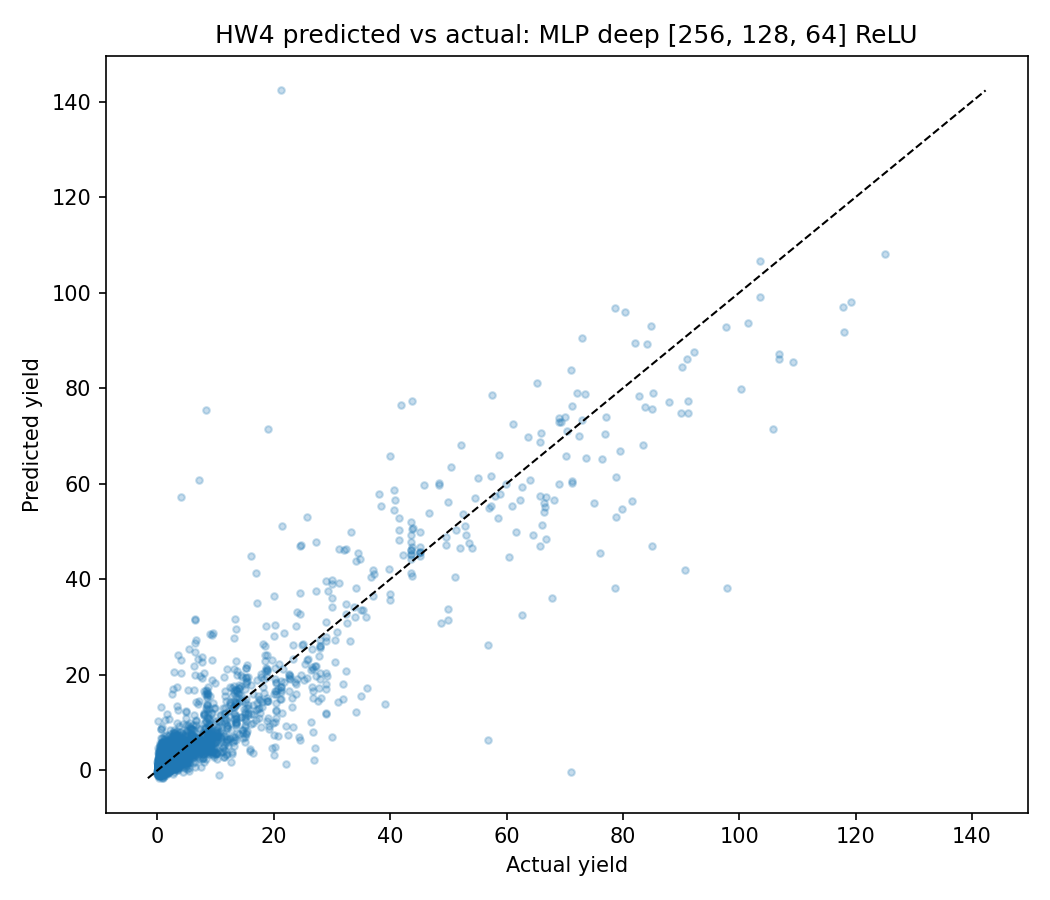

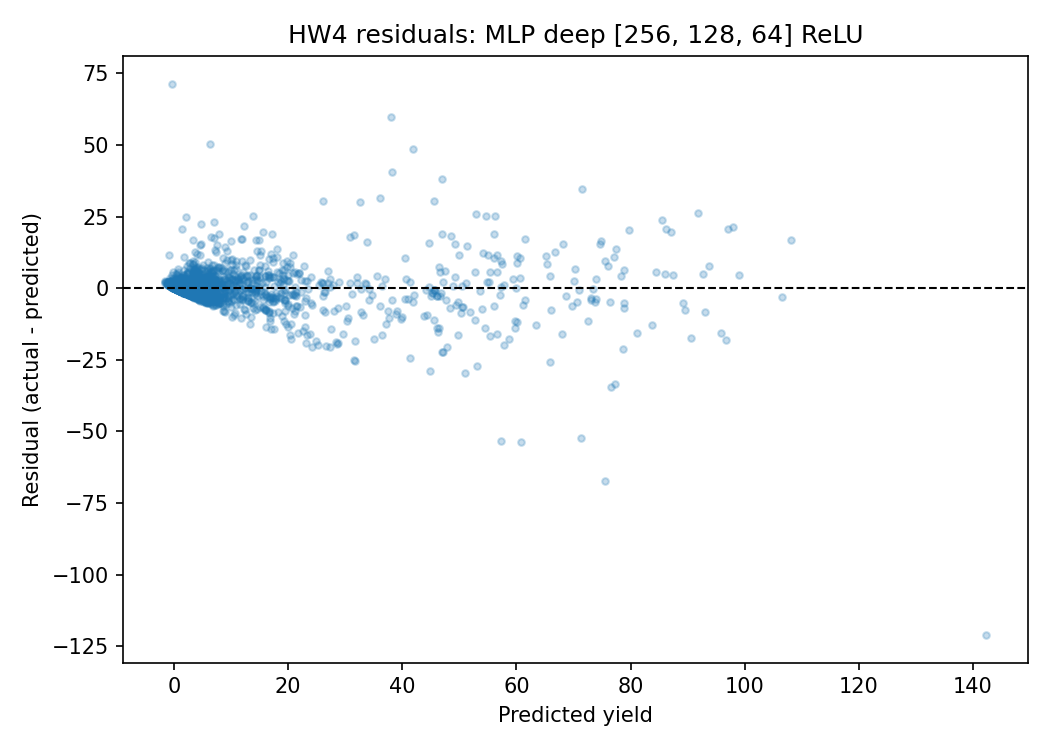

,canonical_state_name,canonical_district_name,Crop_canonical,Season_canonical,Crop_Year,actual_yield,predicted_yield,residual,absolute_error
5371,Jharkhand,DHANBAD,Onion,Rabi,2013,362.000000,5.740006,356.259994,356.259994
3954,Delhi,DELHI_TOTAL,Potato,Whole Year,2013,21.265602,142.354614,-121.089012,121.089012
16556,West Bengal,MEDINIPUR WEST,Sugarcane,Whole Year,2013,220.617757,108.644302,111.973455,111.973455
32325,West Bengal,HOOGHLY,Sugarcane,Whole Year,2014,179.866265,71.936310,107.929955,107.929955
20590,Delhi,DELHI_TOTAL,Potato,Whole Year,2014,21.268349,128.585144,-107.316795,107.316795
3956,Delhi,DELHI_TOTAL,Sugarcane,Whole Year,2013,75.333333,182.381927,-107.048594,107.048594
7902,Madhya Pradesh,KATNI,Banana,Whole Year,2013,138.421053,41.418583,97.002470,97.002470
521,Andhra Pradesh,PRAKASAM,Papaya,Kharif,2013,131.300654,50.706703,80.593950,80.593950
32461,West Bengal,MEDINIPUR WEST,Sugarcane,Whole Year,2014,179.866515,102.493866,77.372649,77.372649
27534,Rajasthan,JAIPUR,Sugarcane,Whole Year,2014,136.111111,61.105656,75.005455,75.005455


In [3]:
from IPython.display import Image, Markdown, display

display(Image(filename=str(ROOT / "results/hw4_predicted_vs_actual.png")))
display(Image(filename=str(ROOT / "results/hw4_residuals_vs_predicted.png")))
artifacts["worst_predictions"]

In [4]:
from IPython.display import Markdown, display

results = artifacts["results"].copy()
best_name = artifacts["best_mlp"]

best_row = results.loc[results["model"].eq(best_name)].iloc[0]
dummy_row = results.loc[results["model"].eq("Dummy mean")].iloc[0]
ridge_row = results.loc[results["model"].eq("Ridge alpha=1")].iloc[0]

summary = f"""## Stručné shrnutí

Nejlepší MLP varianta podle validačního RMSE byla **{best_name}**. Na testovacích letech dosáhla RMSE `{best_row['test_rmse']:.3f}` a R² `{best_row['test_r2']:.3f}`.

Pro srovnání, jednoduchý `Dummy mean` měl test RMSE `{dummy_row['test_rmse']:.3f}` a lineární `Ridge` měl test RMSE `{ridge_row['test_rmse']:.3f}`. MLP tedy v tomto experimentu překonalo jak naivní baseline, tak jednoduchý lineární model.

Podle mě to dává smysl, protože výnos plodin nezávisí jen na jedné proměnné. Důležitá je kombinace plodiny, regionu, sezóny, plochy a počasí. Takový vztah může být nelineární, a proto zde MLP dokázalo fungovat lépe než Ridge.

Výsledek ale neberu jako důkaz, že neuronové sítě jsou vždy nejlepší volba pro tabulková data. V Úkolu 3 se jako velmi silný ukázal Random Forest. Tuto část proto beru spíš jako samostatné rozšíření z workshopu: vyzkoušel jsem MLP v PyTorchi a porovnal několik jeho variant."""
display(Markdown(summary))


## Stručné shrnutí

Nejlepší MLP varianta podle validačního RMSE byla **MLP deep [256, 128, 64] ReLU**. Na testovacích letech dosáhla RMSE `5.169` a R² `0.846`.

Pro srovnání, jednoduchý `Dummy mean` měl test RMSE `13.204` a lineární `Ridge` měl test RMSE `7.360`. MLP tedy v tomto experimentu překonalo jak naivní baseline, tak jednoduchý lineární model.

Podle mě to dává smysl, protože výnos plodin nezávisí jen na jedné proměnné. Důležitá je kombinace plodiny, regionu, sezóny, plochy a počasí. Takový vztah může být nelineární, a proto zde MLP dokázalo fungovat lépe než Ridge.

Výsledek ale neberu jako důkaz, že neuronové sítě jsou vždy nejlepší volba pro tabulková data. V Úkolu 3 se jako velmi silný ukázal Random Forest. Tuto část proto beru spíš jako samostatné rozšíření z workshopu: vyzkoušel jsem MLP v PyTorchi a porovnal několik jeho variant.